In [29]:
# pip install vireoSNP

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import vireoSNP

In [31]:
cwd = os.getcwd()

In [70]:
def match_sample_id():
    
    # match bulk to dissociated bulk
    res = vireoSNP.vcf.match_VCF_samples(
        cwd + "/../data/bcftools/bcftools_bulk_all_rehead.vcf", 
        cwd + "/../data/bcftools/bcftools_diss_bulk_all_rehead.vcf", 
        GT_tag1='PL', 
        GT_tag2='PL',
    )
    
    df = pd.DataFrame(
        {
            "diss bulk sample id": res["matched_donors2"],
            "bulk sample id": res["matched_donors1"],
        }
    )
    # Clean up "sample id" columns
    df = df.replace({r"\d{6}/": ""}, regex=True)
        
    return res, df

In [71]:
res, df = match_sample_id()

Shape for Geno Prob in VCF1: (7489229, 36, 3)
Shape for Geno Prob in VCF2: (3304001, 32, 3)
n_variants in VCF1, VCF2 and matched: 7489229, 3304001, 2228739
aligned donors:
['230509/2018' '230509/2023' '230509/2094' '230509/2126' '230509/2129'
 '230509/2186' '230509/2202' '230509/2209' '230509/2240' '230509/2309'
 '230509/2313' '230509/2401' '230509/2407' '230509/2444' '230509/2483'
 '230509/2526' '230626/2216' '230626/2221' '230626/2230' '230626/2238'
 '230626/2246' '230626/2249' '230626/2268' '230626/2296' '230626/2364'
 '230626/2423' '230626/2430' '230626/2455' '230626/2460' '230626/2466'
 '230626/2477' '230626/2507']
['230414/2018' '230414/2023' '230418/2094' '230414/2126' '230414/2507'
 '230418/2186' '230414/2202' '230418/2216' '230418/2246' '230414/2313'
 '230414/2364' '230414/2407' '230414/2408' '230418/2455' '230414/2526'
 '230414/2209' '230414/2221' '230418/2230' '230414/2238' '230414/2240'
 '230414/2249' '230414/2129' '230414/2278' '230414/2416' '230414/2401'
 '230418/2309' '2

In [34]:
df = pd.DataFrame(
    res["matched_GPb_diff"],
    columns=res["matched_donors2"],
    index=res["matched_donors1"],
)

In [35]:
df.index = df.index.str.replace(r"\d{6}/", "", regex=True)

In [36]:
df.columns = df.columns.str.replace(r"\d{6}/", "", regex=True)

In [38]:
df.head()

,2018,2023,2094,2126,2129,2186,2202,2216,2246,2313,...,2507,2401,2416,2309,2423,2460,2466,2477,2483,2514
2018,0.209361,0.283386,0.280618,0.280415,0.293438,0.283676,0.275173,0.291142,0.291871,0.304074,...,0.333439,0.279779,0.313752,0.288543,0.293494,0.285508,0.289763,0.304238,0.287466,0.299578
2023,0.278813,0.213487,0.269457,0.278056,0.283790,0.274672,0.268875,0.285512,0.278404,0.291689,...,0.316021,0.270957,0.301926,0.272950,0.288454,0.276213,0.273581,0.311994,0.277414,0.291048
2094,0.276635,0.271010,0.207905,0.274787,0.282007,0.273705,0.266816,0.283263,0.278617,0.291016,...,0.316424,0.271508,0.302393,0.276088,0.286875,0.274729,0.274865,0.310145,0.278637,0.287819
2126,0.273360,0.275162,0.271030,0.203492,0.283385,0.273708,0.269930,0.281368,0.279394,0.290863,...,0.318195,0.273745,0.302722,0.281706,0.285023,0.276361,0.277966,0.306092,0.280468,0.289819
2129,0.273289,0.255854,0.255303,0.267771,0.206762,0.259676,0.269478,0.271694,0.251585,0.244248,...,0.257668,0.265258,0.262648,0.259124,0.270166,0.260150,0.244485,0.337444,0.263966,0.270292


In [72]:
pair_df = pd.DataFrame(
    {
        "bulk sample id": res["matched_donors1"],
        "diss bulk sample id":res["matched_donors2"],
    }
).replace(
    r"\d{6}/", "", 
    regex=True
)

In [73]:
filename = cwd + "/../data/sample_pairing_no-filter.csv"
pair_df.to_csv(filename, index=False)

In [55]:
# samples for which we do NOT have diss bulk data
set(pair_df["bulk sample id"])-set(pair_df["diss bulk sample id"])

{'2268', '2296', '2430', '2444'}

In [56]:
# bulk samples that did not match any of the diss bulk samples
set(pair_df["diss bulk sample id"])-set(pair_df["bulk sample id"])

{'2249', '2278', '2416', '2514'}

In [43]:
sorted_df = df.sort_index()

In [44]:
sorted_df = sorted_df.reindex(sorted(sorted_df.columns), axis=1)

In [45]:
sorted_df

,2018,2023,2094,2126,2129,2186,2202,2209,2216,2221,...,2416,2423,2455,2460,2466,2477,2483,2507,2514,2526
2018,0.209361,0.283386,0.280618,0.280415,0.293438,0.283676,0.275173,0.299933,0.291142,0.305397,...,0.313752,0.293494,0.295995,0.285508,0.289763,0.304238,0.287466,0.333439,0.299578,0.292510
2023,0.278813,0.213487,0.269457,0.278056,0.283790,0.274672,0.268875,0.293461,0.285512,0.296713,...,0.301926,0.288454,0.285567,0.276213,0.273581,0.311994,0.277414,0.316021,0.291048,0.278340
2094,0.276635,0.271010,0.207905,0.274787,0.282007,0.273705,0.266816,0.290420,0.283263,0.295167,...,0.302393,0.286875,0.284130,0.274729,0.274865,0.310145,0.278637,0.316424,0.287819,0.279521
2126,0.273360,0.275162,0.271030,0.203492,0.283385,0.273708,0.269930,0.289454,0.281368,0.295847,...,0.302722,0.285023,0.285531,0.276361,0.277966,0.306092,0.280468,0.318195,0.289819,0.282299
2129,0.273289,0.255854,0.255303,0.267771,0.206762,0.259676,0.269478,0.272819,0.271694,0.273218,...,0.262648,0.270166,0.261049,0.260150,0.244485,0.337444,0.263966,0.257668,0.270292,0.251038
2186,0.272905,0.262730,0.262238,0.268599,0.275075,0.199644,0.263267,0.281126,0.274944,0.286682,...,0.288272,0.274349,0.273322,0.265767,0.261050,0.313279,0.269610,0.295365,0.281386,0.268319
2202,0.268141,0.261205,0.258602,0.269623,0.280363,0.264386,0.196342,0.286488,0.279225,0.291318,...,0.287338,0.278993,0.279202,0.268178,0.259065,0.316259,0.264781,0.293439,0.284792,0.263998
2209,0.284565,0.282633,0.279681,0.280886,0.287646,0.280439,0.279447,0.291603,0.212544,0.296760,...,0.307739,0.282231,0.289025,0.278424,0.287020,0.308844,0.288607,0.324382,0.291296,0.290889
2216,0.302175,0.295519,0.294155,0.296203,0.294518,0.293635,0.297348,0.289649,0.298104,0.206878,...,0.311268,0.299541,0.299904,0.294473,0.300069,0.322503,0.305508,0.331077,0.291044,0.304328
2221,0.309532,0.311558,0.311785,0.310416,0.307625,0.310256,0.309350,0.320074,0.306597,0.317800,...,0.330964,0.292104,0.314045,0.310978,0.323949,0.323050,0.319216,0.371787,0.321922,0.320373


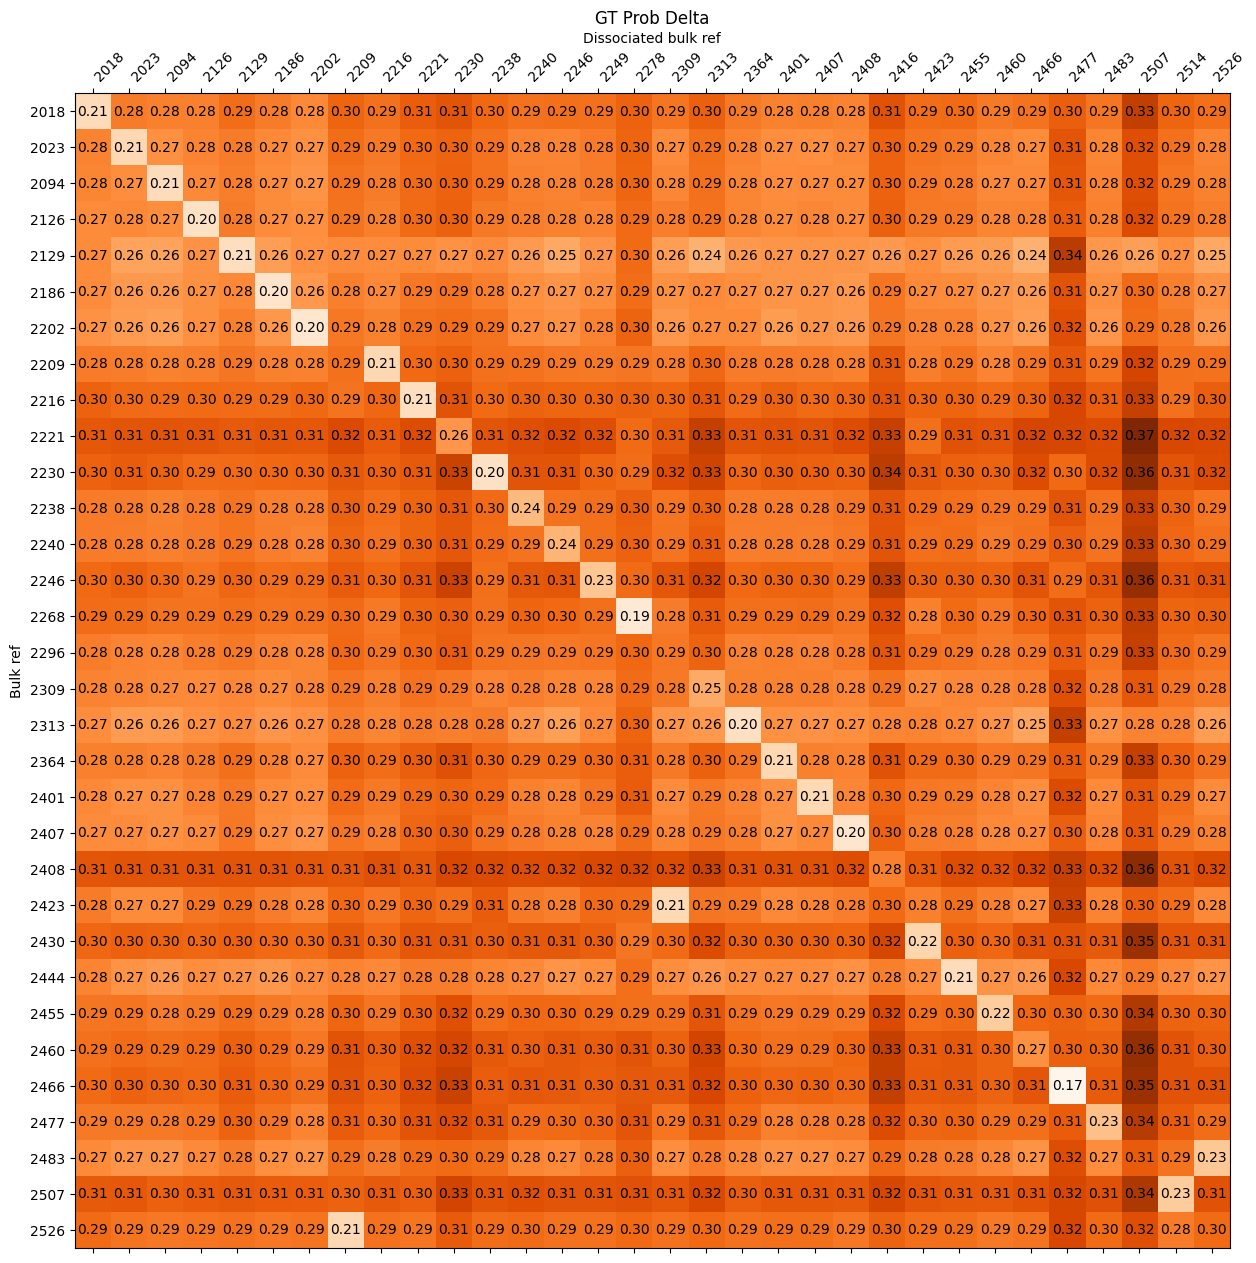

In [46]:
fig, ax = plt.subplots(figsize=(15, 15))
ax.matshow(sorted_df, cmap="Oranges")

# Pool lines
# plt.axhline(y=3.5, color='black', linestyle='--')
# plt.axhline(y=6.5, color='black', linestyle='--')
# plt.axhline(y=10.5, color='black', linestyle='--')
# plt.axhline(y=13.5, color='black', linestyle='--')
# plt.axhline(y=16.5, color='black', linestyle='--')
# plt.axhline(y=20.5, color='black', linestyle='--')
# plt.axhline(y=23.5, color='black', linestyle='--')
# plt.axhline(y=27.5, color='black', linestyle='--')
# plt.axhline(y=30.5, color='black', linestyle='--')

# Numbers in grid
for (i, j), z in np.ndenumerate(sorted_df):
    ax.text(j, i, "{:.2f}".format(z), ha="center", va="center")

ax.set_xticks(np.arange(len(df)))
ax.set_yticks(np.arange(len(df)))
ax.set_xticklabels(sorted_df.columns, rotation=45, ha="left")
ax.set_yticklabels(sorted_df.index)
ax.xaxis.set_label_position("top")
ax.set_xlabel("Dissociated bulk ref")
ax.set_ylabel("Bulk ref")
ax.set_title("GT Prob Delta")

plt.show()

In [47]:
filename = f"../figures/diss_vs_bulk_ref/GT_delta_prob_bulk_vs_diss_bulk_all_numbers_filter2_sorted"
fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".png", bbox_inches="tight")

# Comparing filtering vs no filtering

In [76]:
pair_no_filter = pd.read_csv(cwd + "/../data/sample_pairing_no-filter.csv")
pair_filter1 = pd.read_csv(cwd + "/../data/sample_pairing_filter1.csv")
pair_filter2 = pd.read_csv(cwd + "/../data/sample_pairing_filter2.csv")
pair_filter3 = pd.read_csv(cwd + "/../data/sample_pairing_filter3.csv")

In [153]:
df = pd.merge(pair_no_filter, pair_filter1, on="bulk sample id", suffixes=[" no", " 1"], how="outer")
df = pd.merge(df, pair_filter2, on="bulk sample id", how="outer")
df = pd.merge(df, pair_filter3, on="bulk sample id", suffixes=[" 2", " 3"], how="outer")

In [154]:
df = df.sort_values(by="bulk sample id").reset_index(drop=True)

In [155]:
df["bulk sample id"] = df["bulk sample id"].astype("str")
df["diss bulk sample id no"] = df["diss bulk sample id no"].astype("Int64").astype("str")
df["diss bulk sample id 1"] = df["diss bulk sample id 1"].astype("Int64").astype("str")
df["diss bulk sample id 2"] = df["diss bulk sample id 2"].astype("Int64").astype("str")
df["diss bulk sample id 3"] = df["diss bulk sample id 3"].astype("Int64").astype("str")

In [157]:
cmap=plt.colormaps["gist_rainbow"]

In [160]:
# Get all sample ids, sort, and remove the nan at the end
sample_ids = sorted(set(df["bulk sample id"]) | set(df["diss bulk sample id 1"]) | set(df["diss bulk sample id 2"]) | set(df["diss bulk sample id 3"]) | set(df["diss bulk sample id no"]))[:-1]

In [163]:
color_dict = {
    sample_ids[i]: i for i in range(len(sample_ids))
}

shadow_df = df.copy()
shadow_df.replace(color_dict, inplace=True)

/var/folders/yj/bt5772fx4p1cg9s9jbwzf0r00000gp/T/ipykernel_41197/2684966974.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shadow_df.replace(color_dict, inplace=True)


In [174]:
shadow_df.replace("<NA>", np.nan, inplace=True)

/var/folders/yj/bt5772fx4p1cg9s9jbwzf0r00000gp/T/ipykernel_41197/936780263.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shadow_df.replace("<NA>", np.nan, inplace=True)


In [179]:
shadow_df = shadow_df.astype(float)

In [199]:
reverse_dict = {v: k for k, v in color_dict.items()}

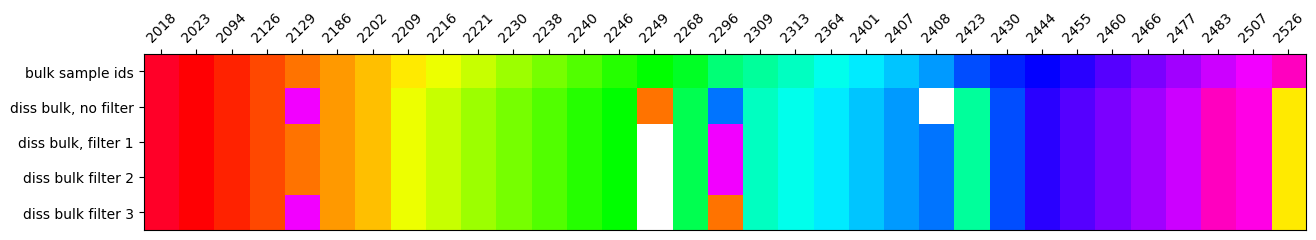

In [207]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))

cmap=plt.colormaps["gist_rainbow"]

plt.imshow(shadow_df.T, cmap="gist_rainbow")
ax.set_xticks(range(len(shadow_df)))
ax.set_xticklabels(
    labels=shadow_df["bulk sample id"].astype(int).replace(reverse_dict),
    rotation=45,
    )
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
ax.set_yticks(range(5))
ax.set_yticklabels(["bulk sample ids", "diss bulk, no filter", "diss bulk, filter 1", "diss bulk filter 2", "diss bulk filter 3"])

plt.show()

In [208]:
filename = f"../figures/diss_vs_bulk_ref/label_matching_heatmap"
fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".png", bbox_inches="tight")